In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# laod the data
df = pd.read_csv('../../data/Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [3]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='str')

### Data Cleaning

* **Handling Missing Values**
    1. Handling Missing Values
    2. Hansdling Duplicates
    3. Check data types
    4. Understand the dataset (Get one with the data)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

In [5]:
df.isna().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [6]:
# Check all the categories
df.Gender.value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [7]:
df.MaritalStatus.value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [8]:
df.TypeofContact.value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [9]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

In [10]:
print(df.Gender.value_counts())
print(df.MaritalStatus.value_counts())

Gender
Male      2916
Female    1972
Name: count, dtype: int64
MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64


In [11]:
# Checking missing values 
# These are the features with nan values
features_with_na = [features for features in df.columns if df[features].isna().sum()>=1]
for feature in features_with_na:
    print(feature, np.round(df[feature].isna().mean()*100,5), '% misisng values')

Age 4.62357 % misisng values
TypeofContact 0.51146 % misisng values
DurationOfPitch 5.13502 % misisng values
NumberOfFollowups 0.92062 % misisng values
PreferredPropertyStar 0.53191 % misisng values
NumberOfTrips 2.86416 % misisng values
NumberOfChildrenVisiting 1.35025 % misisng values
MonthlyIncome 4.76678 % misisng values


In [12]:
# statistics on numerical column (Null cols)
df.isna().select_dtypes(exclude='object').describe().T

,count,unique,top,freq
CustomerID,4888,1,False,4888
ProdTaken,4888,1,False,4888
Age,4888,2,False,4662
TypeofContact,4888,2,False,4863
CityTier,4888,1,False,4888
DurationOfPitch,4888,2,False,4637
Occupation,4888,1,False,4888
Gender,4888,1,False,4888
NumberOfPersonVisiting,4888,1,False,4888
NumberOfFollowups,4888,2,False,4843


### Imputing Null values

And our strategy will be median mode, median mode, ...

In [13]:
# Age 
df['Age'] = df.Age.fillna(df.Age.median())

# TypeofContract 
df['TypeofContact'] = df.TypeofContact.fillna(df.TypeofContact.mode()[0])

# DurationoOfPitch 
df['DurationOfPitch'] = df.DurationOfPitch.fillna(df.DurationOfPitch.median())

# NumberOfFollowUps 
df['NumberOfFollowups'] = df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0])

# PreferredPropertyStar 
df['PreferredPropertyStar'] = df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0])

# NumberofTrips 
df['NumberOfTrips'] = df.NumberOfTrips.fillna(0)

# NumberOfChildrenVisiting 
df['NumberOfChildrenVisiting'] = df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0])

# MonthlyIncome 
df['MonthlyIncome'] = df.MonthlyIncome.fillna(df.MonthlyIncome.median())

In [14]:
df.isna().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [15]:
df.drop('CustomerID', axis=1, inplace=True)

### Feature Engineering 

#### Feature Extraction

In [16]:
# create new colum for features
df['TotalVisiting'] = df.NumberOfPersonVisiting + df.NumberOfChildrenVisiting
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], inplace=True)

In [17]:
df.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfFollowups', 'ProductPitched',
       'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'Designation', 'MonthlyIncome',
       'TotalVisiting'],
      dtype='str')

In [18]:
# Number of numeric features
num_features = df.select_dtypes(include='number').columns
print(f'Number of Numeric features are {len(num_features)}')

Number of Numeric features are 12


In [19]:
# Number of Categorical features
cat_features = df.select_dtypes(include='object').columns
print(f'Number of Categorical features are {len(cat_features)}')

Number of Categorical features are 6


In [20]:
# Discrete features
discrete_features = [feature for feature in num_features if len(df[feature].unique() <= 25)]
print(f'Number of Discrete features are {len(discrete_features)}')

Number of Discrete features are 12


In [21]:
# Continuous features
continuous_features = [feature for feature in num_features if feature not in discrete_features < 25]
print(f'Number of Continuous features are {len(continuous_features)}')

Number of Continuous features are 0


In [22]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


### Train test split and model training

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('ProdTaken', axis=1)
y = df.ProdTaken

In [24]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3910, 17), (978, 17), (3910,), (978,))

In [26]:
# Create Columntransformer with 3 Types of transformers

cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')


preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer, cat_features),
        ('StandardScalar', numeric_transformer, num_features)
    ]
)

In [27]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScalar', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [28]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, \
                            roc_auc_score, roc_curve, precision_score, recall_score, f1_score

In [30]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    # Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    
    # training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)
    
    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model Performance for train set')
    print(f'{model_train_accuracy = :.4f}')
    print(f'{model_train_f1 = :.4f}')
    print(f'{model_train_precision = :.4f}')
    print(f'{model_train_recall = :.4f}')
    print(f'{model_train_rocauc_score = :.4f}')
    
    print('---------------------------------------------')
    
    print('Model Performance for test set')
    print(f'{model_test_accuracy = :.4f}')
    print(f'{model_test_f1 = :.4f}')
    print(f'{model_test_precision = :.4f}')
    print(f'{model_test_recall = :.4f}')
    print(f'{model_test_rocauc_score = :.4f}')
    
    print(f'{"=" * 45}')

Logistic Regression
Model Performance for train set
model_train_accuracy = 0.8458
model_train_f1 = 0.4230
model_train_precision = 0.6994
model_train_recall = 0.3032
model_train_rocauc_score = 0.6366
---------------------------------------------
Model Performance for test set
model_test_accuracy = 0.8354
model_test_f1 = 0.4103
model_test_precision = 0.6829
model_test_recall = 0.2932
model_test_rocauc_score = 0.6301
Decision Tree
Model Performance for train set
model_train_accuracy = 1.0000
model_train_f1 = 1.0000
model_train_precision = 1.0000
model_train_recall = 1.0000
model_train_rocauc_score = 1.0000
---------------------------------------------
Model Performance for test set
model_test_accuracy = 0.9274
model_test_f1 = 0.8127
model_test_precision = 0.8191
model_test_recall = 0.8063
model_test_rocauc_score = 0.8815
Random Forest
Model Performance for train set
model_train_accuracy = 1.0000
model_train_f1 = 1.0000
model_train_precision = 1.0000
model_train_recall = 1.0000
model_train

### Hyperparameter Tunning

In [31]:
rf_params = {
    'max_depth': [5, 8, 15, None, 10],
    'max_features': [5, 7, 'auto', 8],
    'min_samples_split': [2, 8, 15, 20],
    'n_estimators': [100, 200, 500, 1000]
}

In [32]:
# model list for hyperparamter tunning
randomcv_models = [    
        ('RF', RandomForestClassifier(), rf_params),
]

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from tqdm import tqdm

model_params = {}
for name, model, params in tqdm(randomcv_models):
    random = RandomizedSearchCV(estimator=model,
                                param_distributions=params,
                                n_iter=100,
                                cv=3,
                                verbose=0,
                                n_jobs=-1)
    
    random.fit(X_train, y_train)
    model_params[name] = random.best_params_
    
for model_name in model_params:
    print(f"------------  Best Params for {model_name} ------------")
    print(model_params[model_name])

100%|██████████| 1/1 [00:48<00:00, 48.48s/it]

------------  Best Params for RF ------------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 8, 'max_depth': 15}


In [34]:
models = {
    'Random Forst': RandomForestClassifier(n_estimators=500,
                                           min_samples_split=2,
                                           max_features=8,
                                           max_depth=None)
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    # Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    
    # training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)
    
    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model Performance for train set')
    print(f'{model_train_accuracy = :.4f}')
    print(f'{model_train_f1 = :.4f}')
    print(f'{model_train_precision = :.4f}')
    print(f'{model_train_recall = :.4f}')
    print(f'{model_train_rocauc_score = :.4f}')
    
    print('---------------------------------------------')
    
    print('Model Performance for test set')
    print(f'{model_test_accuracy = :.4f}')
    print(f'{model_test_f1 = :.4f}')
    print(f'{model_test_precision = :.4f}')
    print(f'{model_test_recall = :.4f}')
    print(f'{model_test_rocauc_score = :.4f}')
    
    print(f'{"=" * 45}')

Random Forst
Model Performance for train set
model_train_accuracy = 1.0000
model_train_f1 = 1.0000
model_train_precision = 1.0000
model_train_recall = 1.0000
model_train_rocauc_score = 1.0000
---------------------------------------------
Model Performance for test set
model_test_accuracy = 0.9356
model_test_f1 = 0.8073
model_test_precision = 0.9706
model_test_recall = 0.6911
model_test_rocauc_score = 0.8430


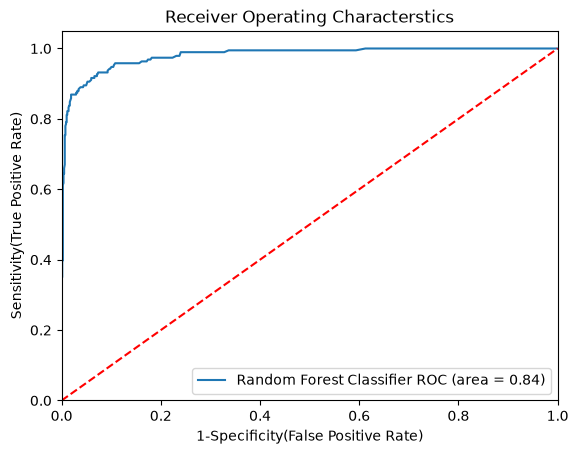

In [35]:
# Plot ROC AUC Curve
plt.figure()

# add the models to the list you want to view in the ROC plot
auc_models = [
    {
    'label': 'Random Forest Classifier',
    'model': RandomForestClassifier(n_estimators=500,
                                           min_samples_split=2,
                                           max_features=8,
                                           max_depth=None),
    'auc': 0.8444
}
]

## looping through the models
for algo in auc_models:
    model = algo['model']
    model.fit(X_train, y_train)
    
# computing fpr, tpr, threshold
    fpr, tpr, threshold = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
# calculate area under the curve to display on the plot
    plt.plot(fpr, tpr, 
             label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom setting for plot
#plt.figure(figsize=(10,15))
plt.plot([0,1], [0,1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characterstics')
plt.legend(loc='lower right')
plt.savefig('../../assets/auc.png')
plt.show()